In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/heat_log.csv")
df.head()

,timestamp,temp_c
0,2026-08-20T15:20:04.420,29.00
1,2026-08-20T15:20:04.420,29.25
2,2026-08-20T15:20:04.420,29.25
3,2026-08-20T15:20:04.421,29.00
4,2026-08-20T15:20:04.421,29.25


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1491 entries, 0 to 1490
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  1491 non-null   str    
 1   temp_c     1491 non-null   float64
dtypes: float64(1), str(1)
memory usage: 23.4 KB


,temp_c
count,1491.000000
mean,41.899564
std,351.801633
min,2.000000
25%,29.000000
50%,29.250000
75%,30.750000
max,13232.000000


In [5]:
df = pd.read_csv("data/heat_log.csv", parse_dates=["timestamp"])
df.dtypes

timestamp    datetime64[us]
temp_c              float64
dtype: object

In [6]:
# حدود فيزيائية للبيئة: تسخين يدوي في غرفة عادية
LOW, HIGH = 10, 60
bad = df[(df.temp_c < LOW) | (df.temp_c > HIGH)]
print(bad)
print("عدد المرفوض:", len(bad))

                 timestamp   temp_c
11 2026-08-20 15:20:04.429      2.0
12 2026-08-20 15:20:04.431   1184.0
13 2026-08-20 15:20:04.434  13232.0
14 2026-08-20 15:20:04.435   3028.0
عدد المرفوض: 4


In [9]:
clean = df[(df.temp_c >= LOW) & (df.temp_c <= HIGH)]
clean.temp_c.describe()

count    1487.000000
mean       30.279926
std         2.113939
min        28.750000
25%        29.000000
50%        29.250000
75%        30.750000
max        46.000000
Name: temp_c, dtype: float64

In [10]:
dt = df["timestamp"].diff().dt.total_seconds()
print(dt.describe())
print(dt.value_counts().head())

count    1490.000000
mean        1.019860
std         0.101203
min         0.000000
25%         1.029000
50%         1.030000
75%         1.030000
max         1.038000
Name: timestamp, dtype: float64
timestamp
1.030    825
1.028    229
1.029     92
1.032     83
1.034     72
Name: count, dtype: int64


In [11]:
dt = df["timestamp"].diff().dt.total_seconds()
clean = df[dt > 0.999]
print(len(clean))
clean["temp_c"].describe()

1475


count    1475.000000
mean       30.277797
std         2.080285
min        28.750000
25%        29.000000
50%        29.250000
75%        30.750000
max        35.750000
Name: temp_c, dtype: float64

In [13]:
clean.head()

,timestamp,temp_c
16,2026-08-20 15:20:05.736,29.25
17,2026-08-20 15:20:06.768,29.25
18,2026-08-20 15:20:07.797,29.25
19,2026-08-20 15:20:08.827,29.25
20,2026-08-20 15:20:09.857,29.25


<Axes: xlabel='timestamp'>

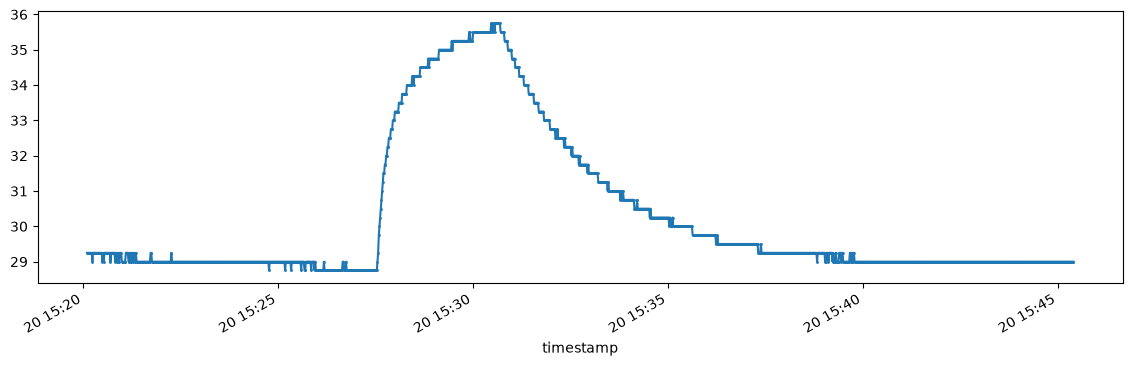

In [14]:
clean = clean.set_index("timestamp")
clean["temp_c"].plot(figsize=(14, 4), marker=".", markersize=2)

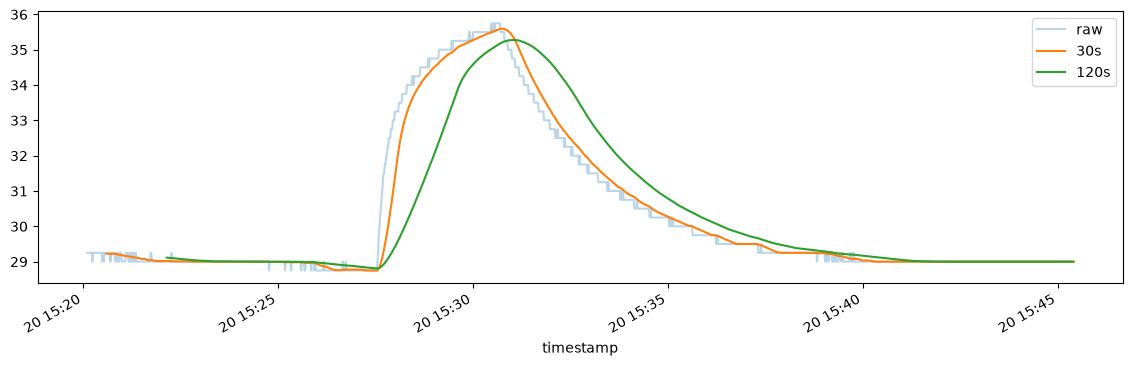

In [17]:
clean["temp_c"].plot(figsize=(14,4), alpha=0.3, label="raw")
clean["temp_c"].rolling(30).mean().plot(label="30s")
clean["temp_c"].rolling(120).mean().plot(label="120s")
plt.legend()

<Axes: xlabel='timestamp'>

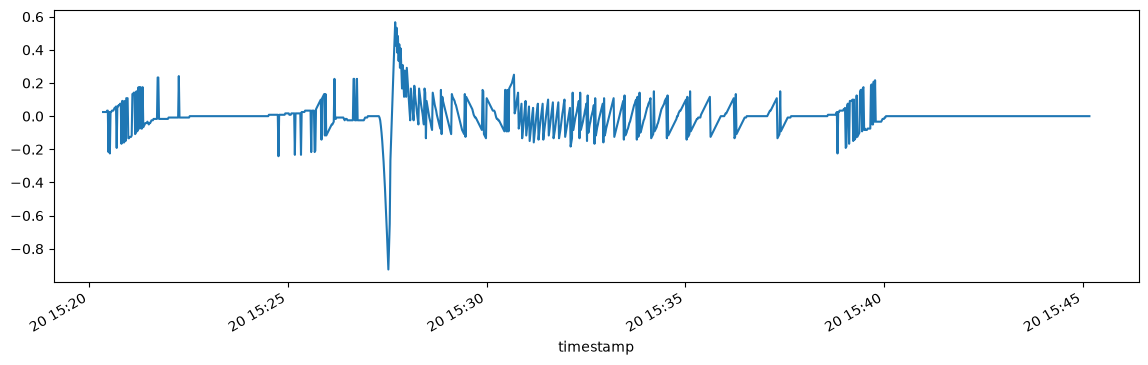

In [18]:
resid = clean["temp_c"] - clean["temp_c"].rolling(30, center=True).mean()
resid.plot(figsize=(14, 4))

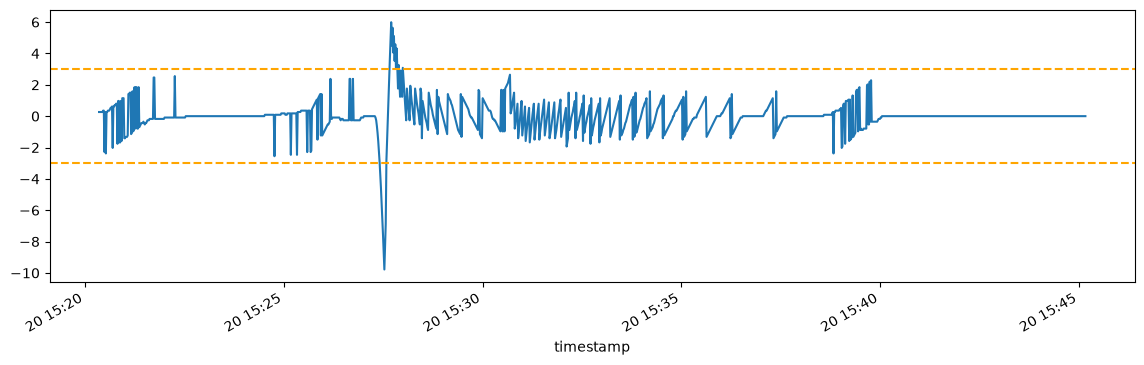

In [19]:
z = resid / resid.std()
z.plot(figsize=(14, 4))
plt.axhline(3, color="orange", linestyle="--")
plt.axhline(-3, color="orange", linestyle="--")